# Dataset 1: ATP Tennis Matches — Predicting Match Winner

## Overview

We use the ATP match-level dataset (2015–2024) to build a binary classification problem.

**Key idea — symmetrization:** The raw data has one row per match with columns labelled
`winner_*` / `loser_*`. If we naïvely compute winner-minus-loser differentials, the
features perfectly encode the outcome (the winner always has the better stats by
construction). To avoid this **target leakage** we randomly assign the two players in
each match to "Player A" and "Player B" positions with a fair coin flip:

| Coin | Player A | Player B | Target (Y) |
|------|----------|----------|------------|
| Heads | Winner | Loser | 1 (A won) |
| Tails | Loser | Winner | 0 (A lost) |

**Target (Y):** Did Player A win the match? (1 = yes, 0 = no)  
By construction the target is balanced (~50 / 50).

**Features (X):** Player-A-minus-Player-B differentials:
- Rank & rating differentials, age & height differentials
- Service statistics (ace rate, double-fault rate, 1st-serve %, break-point save %, …)
- Match-level contextual features (minutes, best-of format, total service points)

This is a non-trivial, interesting dataset because:
1. Tennis match outcomes depend on subtle interactions between player attributes and in-match performance.
2. The balanced target and ~25k rows provide a solid experimental base.
3. There are many numerical features arising from detailed match statistics.

---

In [3]:
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

# Add scripts directory to path so we can import our utilities
PROJ_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(PROJ_ROOT, "scripts"))

from scripts.preprocessing import full_preprocessing_pipeline, impute_missing
from scripts.missing_data import generate_missing, missingness_summary, SCHEME_REGISTRY

print("Project root:", PROJ_ROOT)

Project root: /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/Project 1


## 1. Load and Concatenate Raw Data

We use the main ATP tour singles match files from 2015 to 2024 (excluding doubles, futures, and qualifying/challenger data). This gives us roughly 25k+ matches with modern, detailed statistics.

In [4]:
DATA_DIR = os.path.join(PROJ_ROOT, "datasets")

years = range(1968, 2025)
files = [os.path.join(DATA_DIR, f"atp_matches_{y}.csv") for y in years]
files = [f for f in files if os.path.exists(f)]

print(f"Loading {len(files)} files...")
dfs = [pd.read_csv(f) for f in files]
df_raw = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {df_raw.shape}")
df_raw.head(3)

Loading 57 files...
Combined shape: (194996, 49)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,1968-2029,Dublin,Grass,32.0,A,19680708,270,112411,NaN,NaN,Doug Smith,U,NaN,AUS,NaN,110196,NaN,NaN,Peter Ledbetter,U,NaN,IRL,24.0,6-1 7-5,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1968-2029,Dublin,Grass,32.0,A,19680708,271,126914,NaN,NaN,Louis Pretorius,R,NaN,RSA,NaN,209536,NaN,NaN,Maurice Pollock,U,NaN,IRL,NaN,6-1 6-1,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1968-2029,Dublin,Grass,32.0,A,19680708,272,209523,NaN,NaN,Cecil Pedlow,U,NaN,IRL,NaN,209535,NaN,NaN,John Mulvey,U,NaN,IRL,NaN,6-2 6-2,3,R32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Column dtypes:")
print(df_raw.dtypes)
print()
print("Missing values per column:")
print(df_raw.isnull().sum())

Column dtypes:
tourney_id                str
tourney_name              str
surface                   str
draw_size             float64
tourney_level             str
tourney_date            int64
match_num               int64
winner_id               int64
winner_seed           float64
winner_entry              str
winner_name               str
winner_hand               str
winner_ht             float64
winner_ioc                str
winner_age            float64
loser_id                int64
loser_seed            float64
loser_entry               str
loser_name                str
loser_hand                str
loser_ht              float64
loser_ioc                 str
loser_age             float64
score                     str
best_of                 int64
round                     str
minutes               float64
w_ace                 float64
w_df                  float64
w_svpt                float64
w_1stIn               float64
w_1stWon              float64
w_2ndWon              flo

## 2. Filter Rows with Required Columns

We need:
- Both players' ranks (to compute rank differential features)
- Complete service statistics (aces, double faults, serve points, …)
- Match duration in minutes

In [6]:
# Drop rows without rank information
df = df_raw.dropna(subset=["winner_rank", "loser_rank"]).copy()
print(f"Rows with rank info: {len(df)} (dropped {len(df_raw) - len(df)})")

# Drop rows where service stats are missing
service_cols = [
    "w_ace", "w_df", "w_svpt", "w_1stIn", "w_1stWon", "w_2ndWon",
    "w_SvGms", "w_bpSaved", "w_bpFaced",
    "l_ace", "l_df", "l_svpt", "l_1stIn", "l_1stWon", "l_2ndWon",
    "l_SvGms", "l_bpSaved", "l_bpFaced",
]
df = df.dropna(subset=service_cols).copy()
print(f"Rows with complete service stats: {len(df)}")

# Also need minutes
df = df.dropna(subset=["minutes"]).copy()
print(f"Rows also with minutes: {len(df)}")

Rows with rank info: 146893 (dropped 48103)
Rows with complete service stats: 97124
Rows also with minutes: 94131


## 3. Symmetrize: Randomly Assign Players to A / B Positions

For each match we flip a fair coin:
- **Heads (flip=1):** Player A = winner, Player B = loser → Y = 1 (A won)
- **Tails (flip=0):** Player A = loser, Player B = winner → Y = 0 (A lost)

This removes the structural leak where winner-side features *always* correspond
to the winning player.

> **Seed note:** We use `random_state=0` for the coin flip and `random_state=121553223`
> for missing-data generation later. Using the *same* seed for both would create
> correlated random sequences and break the MCAR symmetry property.

In [7]:
SYMMETRIZE_SEED = 2978351  # different from missing-data seed (42) to avoid correlation

rng = np.random.default_rng(SYMMETRIZE_SEED)
n = len(df)
flip = rng.binomial(1, 0.5, size=n).astype(bool)  # True = keep winner as A

sym = pd.DataFrame(index=df.index)

# --- Player-level columns: swap according to coin flip ---
winner_loser_pairs = [
    ("winner_rank", "loser_rank"),
    ("winner_rank_points", "loser_rank_points"),
    ("winner_age", "loser_age"),
    ("winner_ht", "loser_ht"),
]
for w_col, l_col in winner_loser_pairs:
    a_col = w_col.replace("winner_", "a_")
    b_col = w_col.replace("winner_", "b_")
    sym[a_col] = np.where(flip, df[w_col], df[l_col])
    sym[b_col] = np.where(flip, df[l_col], df[w_col])

# --- Service-stat columns ---
w_stat_cols = ["w_ace", "w_df", "w_svpt", "w_1stIn", "w_1stWon",
               "w_2ndWon", "w_SvGms", "w_bpSaved", "w_bpFaced"]
l_stat_cols = ["l_ace", "l_df", "l_svpt", "l_1stIn", "l_1stWon",
               "l_2ndWon", "l_SvGms", "l_bpSaved", "l_bpFaced"]

for w_col, l_col in zip(w_stat_cols, l_stat_cols):
    a_col = w_col.replace("w_", "a_")
    b_col = w_col.replace("w_", "b_")
    sym[a_col] = np.where(flip, df[w_col], df[l_col])
    sym[b_col] = np.where(flip, df[l_col], df[w_col])

# --- Match-level columns (no flipping needed) ---
sym["minutes"] = df["minutes"].values
sym["best_of"] = df["best_of"].values

# --- Target ---
sym["y"] = flip.astype(int)

print(f"Symmetrized shape: {sym.shape}")
print(f"Target balance: y=1 (A won) {sym['y'].mean():.3f}")

Symmetrized shape: (94131, 29)
Target balance: y=1 (A won) 0.502


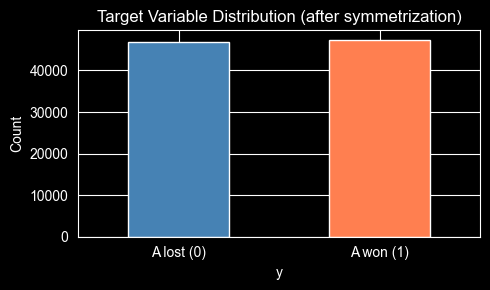

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
sym["y"].value_counts().sort_index().plot.bar(
    ax=ax, color=["steelblue", "coral"]
)
ax.set_xticklabels(["A lost (0)", "A won (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Variable Distribution (after symmetrization)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

We engineer numerical features from the symmetrized match data. The key ideas:

1. **Rank & rating differentials (A − B):** `rank_diff`, `rank_points_diff`, `log_rank_ratio`
2. **Player attribute differentials:** `age_diff`, `height_diff`
3. **Service statistics as rates:** Convert raw counts to percentages/rates for both A and B, then take differentials.
4. **Normalized count differentials:** Raw count differences divided by totals.
5. **Match-level features:** `minutes`, `best_of`, `total_svpt`, `total_games`
6. **Absolute averages (symmetric):** `avg_rank`, `avg_age`, `avg_height`

Using differentials (A − B) ensures the features are naturally numeric and captures
the competitive dynamic of the match without leaking the outcome.

In [9]:
eps = 1e-6  # avoid division by zero

# --- Service rates for Player A ---
sym["a_ace_rate"] = sym["a_ace"] / (sym["a_svpt"] + eps)
sym["a_df_rate"] = sym["a_df"] / (sym["a_svpt"] + eps)
sym["a_1stIn_pct"] = sym["a_1stIn"] / (sym["a_svpt"] + eps)
sym["a_1stWon_pct"] = sym["a_1stWon"] / (sym["a_1stIn"] + eps)
sym["a_2ndWon_pct"] = sym["a_2ndWon"] / (
    (sym["a_svpt"] - sym["a_1stIn"]).clip(lower=eps)
)
sym["a_bp_save_pct"] = sym["a_bpSaved"] / (sym["a_bpFaced"] + eps)
sym["a_hold_pressure"] = sym["a_bpFaced"] / (sym["a_SvGms"] + eps)

# --- Service rates for Player B ---
sym["b_ace_rate"] = sym["b_ace"] / (sym["b_svpt"] + eps)
sym["b_df_rate"] = sym["b_df"] / (sym["b_svpt"] + eps)
sym["b_1stIn_pct"] = sym["b_1stIn"] / (sym["b_svpt"] + eps)
sym["b_1stWon_pct"] = sym["b_1stWon"] / (sym["b_1stIn"] + eps)
sym["b_2ndWon_pct"] = sym["b_2ndWon"] / (
    (sym["b_svpt"] - sym["b_1stIn"]).clip(lower=eps)
)
sym["b_bp_save_pct"] = sym["b_bpSaved"] / (sym["b_bpFaced"] + eps)
sym["b_hold_pressure"] = sym["b_bpFaced"] / (sym["b_SvGms"] + eps)

print("Rate features computed.")

Rate features computed.


In [10]:
# Impute height with median before computing diffs
a_ht = sym["a_ht"].fillna(sym["a_ht"].median())
b_ht = sym["b_ht"].fillna(sym["b_ht"].median())

total_svpt = sym["a_svpt"] + sym["b_svpt"] + eps

feature_dict = {
    # --- Rank & rating differentials (A − B) ---
    "rank_diff": sym["a_rank"] - sym["b_rank"],
    "rank_points_diff": sym["a_rank_points"] - sym["b_rank_points"],
    "log_rank_ratio": np.log1p(sym["a_rank"]) - np.log1p(sym["b_rank"]),
    # --- Player attribute differentials ---
    "age_diff": sym["a_age"] - sym["b_age"],
    "height_diff": a_ht - b_ht,
    # --- Service stat differentials (rates) ---
    "ace_rate_diff": sym["a_ace_rate"] - sym["b_ace_rate"],
    "df_rate_diff": sym["a_df_rate"] - sym["b_df_rate"],
    "first_in_pct_diff": sym["a_1stIn_pct"] - sym["b_1stIn_pct"],
    "first_won_pct_diff": sym["a_1stWon_pct"] - sym["b_1stWon_pct"],
    "second_won_pct_diff": sym["a_2ndWon_pct"] - sym["b_2ndWon_pct"],
    "bp_save_pct_diff": sym["a_bp_save_pct"] - sym["b_bp_save_pct"],
    "hold_pressure_diff": sym["a_hold_pressure"] - sym["b_hold_pressure"],
    # --- Normalized count differentials ---
    "ace_count_diff": (sym["a_ace"] - sym["b_ace"]) / total_svpt,
    "df_count_diff": (sym["a_df"] - sym["b_df"]) / total_svpt,
    "svpt_diff": (sym["a_svpt"] - sym["b_svpt"]) / total_svpt,
    "bp_faced_diff": (
        (sym["a_bpFaced"] - sym["b_bpFaced"])
        / (sym["a_SvGms"] + sym["b_SvGms"] + eps)
    ),
    # --- Match-level features (symmetric, no leak) ---
    "minutes": sym["minutes"],
    "best_of": sym["best_of"].astype(float),
    "total_svpt": sym["a_svpt"] + sym["b_svpt"],
    "total_games": sym["a_SvGms"] + sym["b_SvGms"],
    # --- Absolute averages (symmetric) ---
    "avg_rank": (sym["a_rank"] + sym["b_rank"]) / 2.0,
    "avg_age": (sym["a_age"] + sym["b_age"]) / 2.0,
    "avg_height": (a_ht + b_ht) / 2.0,
}

X = pd.DataFrame(feature_dict, index=sym.index)
y = sym["y"].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features ({len(X.columns)}): {list(X.columns)}")
print(f"Target shape: {y.shape}, y=1 rate: {y.mean():.3f}")

Feature matrix shape: (94131, 23)
Features (23): ['rank_diff', 'rank_points_diff', 'log_rank_ratio', 'age_diff', 'height_diff', 'ace_rate_diff', 'df_rate_diff', 'first_in_pct_diff', 'first_won_pct_diff', 'second_won_pct_diff', 'bp_save_pct_diff', 'hold_pressure_diff', 'ace_count_diff', 'df_count_diff', 'svpt_diff', 'bp_faced_diff', 'minutes', 'best_of', 'total_svpt', 'total_games', 'avg_rank', 'avg_age', 'avg_height']
Target shape: (94131,), y=1 rate: 0.502


In [11]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
rank_diff,94131.0,-0.002029,141.514191,-2.125000e+03,-43.000000,-1.000000,43.000000,2.090000e+03
rank_points_diff,93196.0,-2.131347,1888.111699,-1.651600e+04,-523.000000,2.000000,526.000000,1.664100e+04
log_rank_ratio,94131.0,-0.000993,1.418733,-6.530148e+00,-0.907557,-0.014389,0.905709,5.680173e+00
age_diff,94124.0,-0.028468,5.198034,-2.160000e+01,-3.500000,0.000000,3.400000,2.590000e+01
height_diff,94131.0,0.016573,9.271748,-1.760000e+02,-5.000000,0.000000,5.000000,1.300000e+02
ace_rate_diff,94131.0,0.000227,0.081406,-5.723683e-01,-0.044539,0.000000,0.044810,7.499998e-01
df_rate_diff,94131.0,-0.000049,0.040344,-4.090908e-01,-0.023775,0.000000,0.023607,4.999999e-01
first_in_pct_diff,94131.0,0.000370,0.115284,-7.142857e-01,-0.074261,0.000401,0.074985,9.999998e-01
first_won_pct_diff,94131.0,0.000227,0.159857,-9.999999e-01,-0.104508,0.000000,0.104167,9.999999e-01
second_won_pct_diff,94131.0,0.000582,0.184610,-1.000000e+00,-0.117490,0.000000,0.118593,1.000000e+00


## 5. Preprocessing: Imputation, Collinearity Removal

We now apply our preprocessing pipeline from `scripts/preprocessing.py`:
1. Impute any remaining missing values (median for numeric).
2. Drop low-variance features.
3. Remove collinear features (correlation threshold = 0.90).
4. Remove collinear features (VIF threshold = 10).

In [12]:
# Check for remaining missing values in features
print("Missing values in X before preprocessing:")
missing_counts = X.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "None")

Missing values in X before preprocessing:
rank_points_diff    935
age_diff              7
avg_age               7
dtype: int64


In [13]:
# Create a working DataFrame with features + target
df_work = X.copy()
df_work["y"] = y

feature_cols = list(X.columns)

df_clean, final_features = full_preprocessing_pipeline(
    df_work,
    feature_cols=feature_cols,
    target_col="y",
    impute=True,
    corr_threshold=0.90,
    vif_threshold=10.0,
    do_standardize=False,  # we standardize later if needed
    verbose=True,
)

print(f"\nFinal feature set ({len(final_features)} features):")
for i, col in enumerate(final_features, 1):
    print(f"  {i:2d}. {col}")

Starting preprocessing: 94131 rows, 23 features, target='y'
  Missing values: 949
  After imputation: 0 missing values remain
[correlation] Dropping 3 collinear features (|r| > 0.9): ['ace_rate_diff', 'df_count_diff', 'total_svpt']
[VIF] Dropping 'avg_height' (VIF = 100.6)
[VIF] Dropping 'total_games' (VIF = 62.1)
[VIF] Dropping 'best_of' (VIF = 23.7)
[VIF] Total dropped: 3 columns
Preprocessing complete: 94131 rows, 17 features remaining

Final feature set (17 features):
   1. rank_diff
   2. rank_points_diff
   3. log_rank_ratio
   4. age_diff
   5. height_diff
   6. df_rate_diff
   7. first_in_pct_diff
   8. first_won_pct_diff
   9. second_won_pct_diff
  10. bp_save_pct_diff
  11. hold_pressure_diff
  12. ace_count_diff
  13. svpt_diff
  14. bp_faced_diff
  15. minutes
  16. avg_rank
  17. avg_age


In [14]:
# Extract final X and y
X_final = df_clean[final_features].copy()
y_final = df_clean["y"].values

print(f"Final X shape: {X_final.shape}")
print(f"Final y shape: {y_final.shape}, y=1 rate: {y_final.mean():.3f}")
print(f"Any NaN in X? {X_final.isnull().any().any()}")
print(f"Any NaN in y? {np.isnan(y_final).any()}")

Final X shape: (94131, 17)
Final y shape: (94131,), y=1 rate: 0.502
Any NaN in X? False
Any NaN in y? False


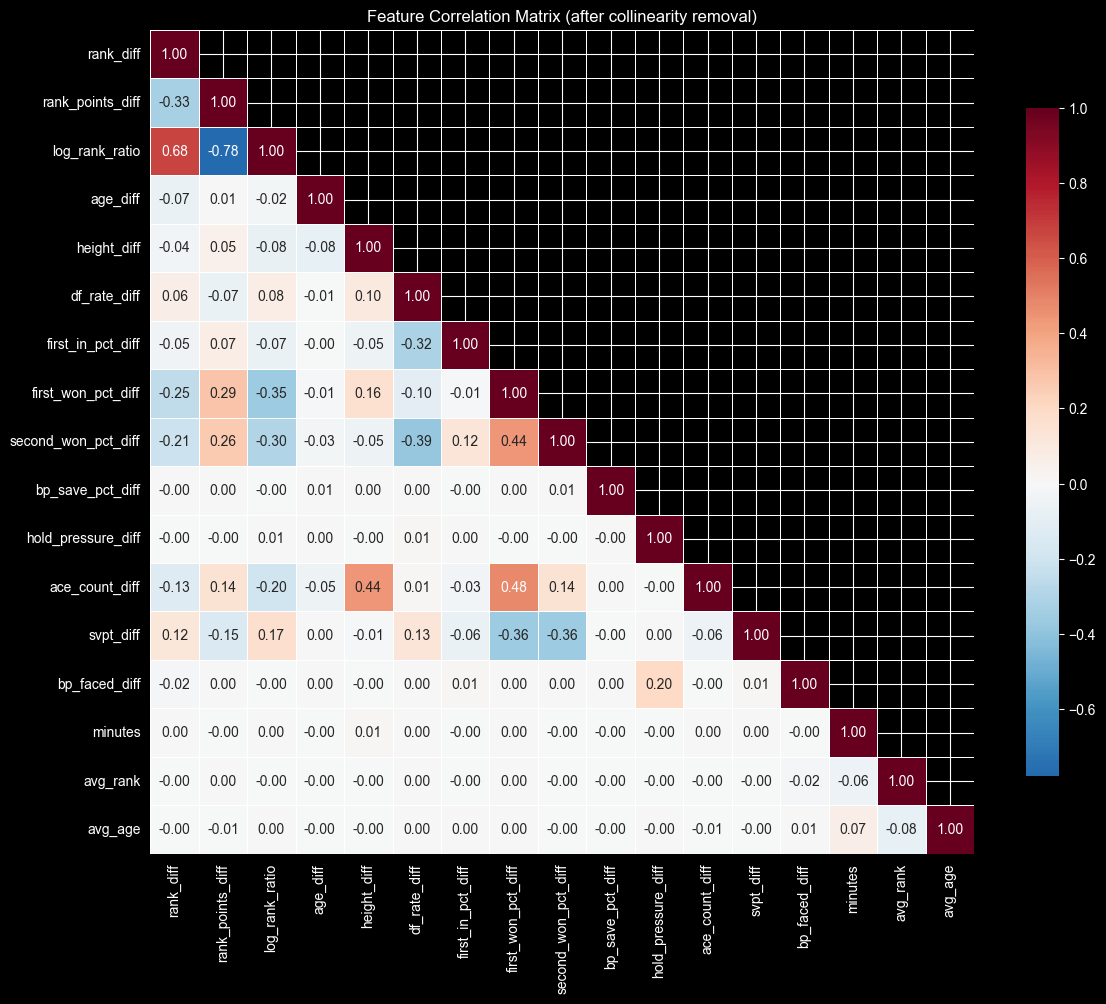

In [15]:
# Correlation heatmap of final features
fig, ax = plt.subplots(figsize=(12, 10))
corr = X_final.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", square=True, linewidths=0.5,
    ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (after collinearity removal)")
plt.tight_layout()
plt.show()

## 6. Save Processed Dataset

We save the fully-labelled, preprocessed dataset to `processed/atp_upset.csv`. This is the "ground truth" dataset from which we will generate missing labels in the next step.

In [16]:
PROCESSED_DIR = os.path.join(PROJ_ROOT, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save: features + target
df_save = X_final.copy()
df_save["y"] = y_final
save_path = os.path.join(PROCESSED_DIR, "atp_upset.csv")
df_save.to_csv(save_path, index=False)
print(f"Saved processed dataset to: {save_path}")
print(f"Shape: {df_save.shape}")
df_save.head()

Saved processed dataset to: /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/Project 1/processed/atp_upset.csv
Shape: (94131, 18)


,rank_diff,rank_points_diff,log_rank_ratio,age_diff,height_diff,df_rate_diff,first_in_pct_diff,first_won_pct_diff,second_won_pct_diff,bp_save_pct_diff,hold_pressure_diff,ace_count_diff,svpt_diff,bp_faced_diff,minutes,avg_rank,avg_age,y
86621,54.0,2.0,2.944439,-2.4,3.0,-0.010746,-0.079715,-0.000587,-0.087214,-0.250000,-0.233333,-0.010471,0.005236,-0.129032,130.0,29.0,21.90,1
86622,229.0,2.0,1.389578,2.8,20.0,0.015794,0.066360,-0.050087,-0.072351,0.400000,0.533333,0.059459,0.091892,0.266667,119.0,189.5,26.00,1
86623,13.0,2.0,0.170345,1.8,7.0,-0.014815,-0.042593,0.179599,0.304348,0.499999,-0.875000,0.035088,-0.052632,-0.437500,71.0,75.5,23.90,1
86624,34.0,2.0,0.510826,1.1,2.0,0.040541,-0.058559,-0.083333,-0.320690,-0.375000,0.466667,0.007463,0.104478,0.263158,85.0,67.0,20.25,0
86625,-60.0,2.0,-1.121341,-4.5,3.0,-0.001804,-0.023088,-0.142073,-0.020833,-0.375000,-0.072727,-0.013423,0.033557,0.000000,90.0,58.0,22.15,0


## 7. Generate Missing Labels (Four Schemes)

We now apply the four missing-data generation schemes from `scripts/missing_data.py` to produce (X, Y_obs) versions of the dataset.

For each scheme, we use a missing rate of **30%** (c = 0.3).

| Scheme | Description | P(S=1 \| X, Y) |
|--------|-------------|------------------|
| MCAR   | Completely random | c = 0.3 |
| MAR1   | Depends on single feature | σ(α·X_j + b) |
| MAR2   | Depends on all features | σ(X·w + b) |
| MNAR   | Depends on X and Y | σ(X·w + γ·Y + b) |

In [17]:
MISSING_RATE = 0.3
RANDOM_STATE = 1337  # different from SYMMETRIZE_SEED to avoid correlated sequences

results = {}

for scheme_name in ["MCAR", "MAR1", "MAR2", "MNAR"]:
    _, y_obs, probs = generate_missing(
        scheme=scheme_name,
        X=X_final,
        y=y_final,
        missing_rate=MISSING_RATE,
        random_state=RANDOM_STATE,
    )
    summary = missingness_summary(y_final, y_obs)
    results[scheme_name] = {
        "y_obs": y_obs,
        "probs": probs,
        "summary": summary,
    }
    print(f"\n{'='*50}")
    print(f"Scheme: {scheme_name}")
    print(f"{'='*50}")
    for k, v in summary.items():
        if isinstance(v, float):
            print(f"  {k:25s}: {v:.4f}")
        else:
            print(f"  {k:25s}: {v}")


Scheme: MCAR
  n_total                  : 94131
  n_missing                : 28266
  n_observed               : 65865
  missing_rate             : 0.3003
  missing_rate_class0      : 0.3000
  missing_rate_class1      : 0.3006

Scheme: MAR1
  n_total                  : 94131
  n_missing                : 27963
  n_observed               : 66168
  missing_rate             : 0.2971
  missing_rate_class0      : 0.1774
  missing_rate_class1      : 0.4157

Scheme: MAR2
  n_total                  : 94131
  n_missing                : 28394
  n_observed               : 65737
  missing_rate             : 0.3016
  missing_rate_class0      : 0.3167
  missing_rate_class1      : 0.2867

Scheme: MNAR
  n_total                  : 94131
  n_missing                : 27972
  n_observed               : 66159
  missing_rate             : 0.2972
  missing_rate_class0      : 0.1404
  missing_rate_class1      : 0.4525


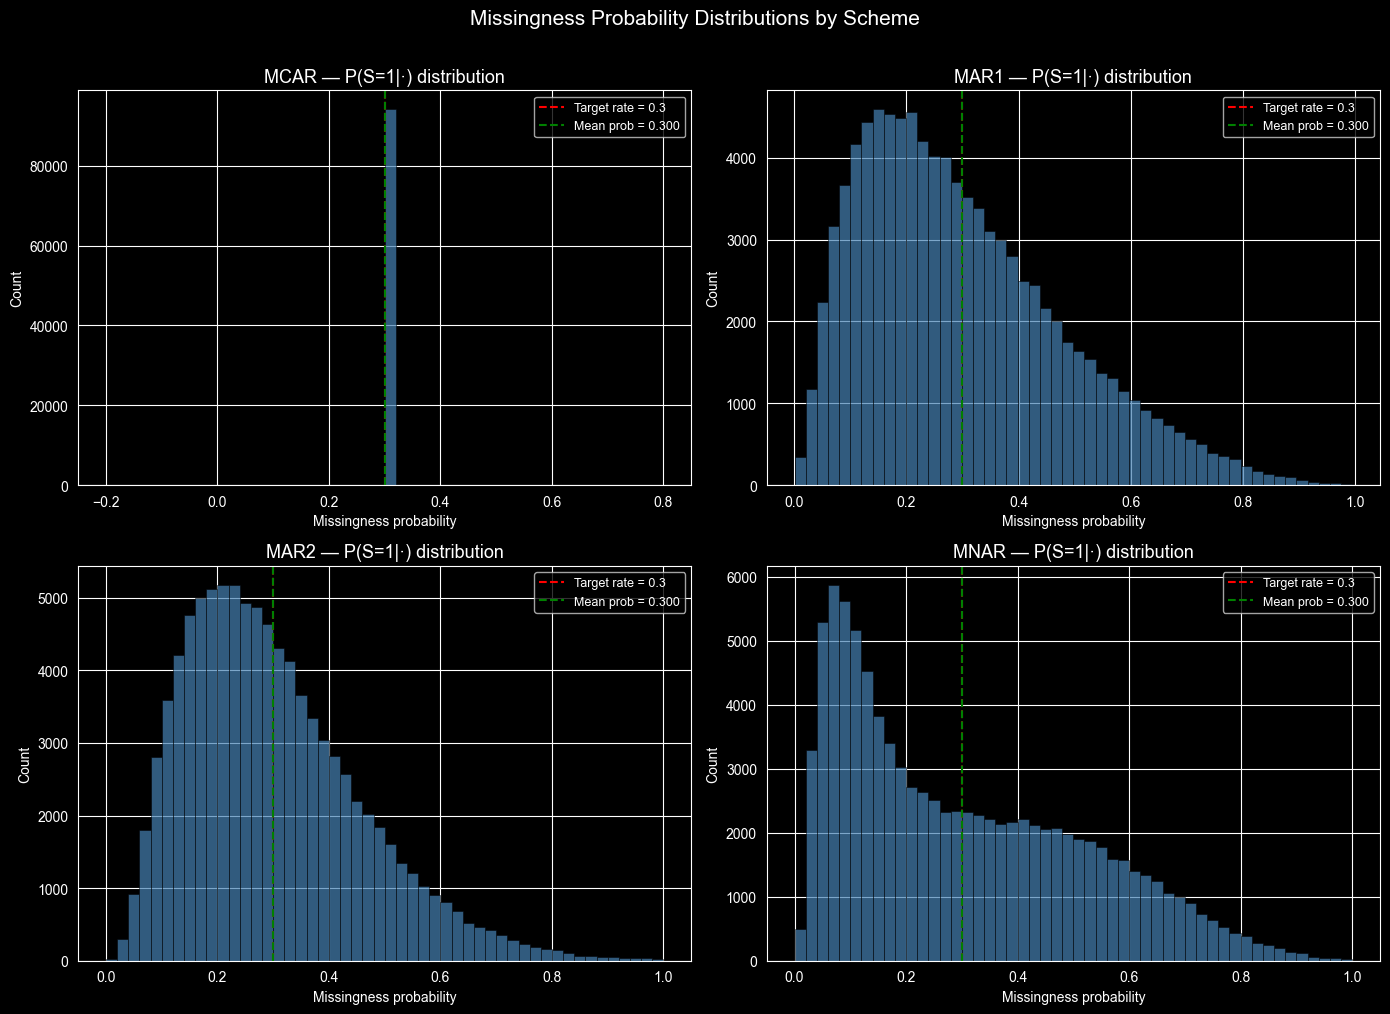

In [18]:
# Visualize missingness probability distributions for each scheme
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
schemes = ["MCAR", "MAR1", "MAR2", "MNAR"]

for ax, scheme_name in zip(axes.ravel(), schemes):
    probs = results[scheme_name]["probs"]
    summary = results[scheme_name]["summary"]

    ax.hist(
        probs, bins=50, alpha=0.7, color="steelblue",
        edgecolor="black", linewidth=0.5,
    )
    ax.axvline(
        MISSING_RATE, color="red", linestyle="--", linewidth=1.5,
        label=f"Target rate = {MISSING_RATE}",
    )
    ax.axvline(
        probs.mean(), color="green", linestyle="--", linewidth=1.5,
        label=f"Mean prob = {probs.mean():.3f}",
    )
    ax.set_title(f"{scheme_name} — P(S=1|·) distribution", fontsize=13)
    ax.set_xlabel("Missingness probability")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle(
    "Missingness Probability Distributions by Scheme", fontsize=15, y=1.01
)
plt.tight_layout()
plt.show()

In [19]:
# Compare per-class missing rates: key diagnostic for MNAR vs others
comparison = pd.DataFrame(
    {
        scheme: {
            "Overall missing rate": results[scheme]["summary"]["missing_rate"],
            "Missing rate (Y=0)": results[scheme]["summary"][
                "missing_rate_class0"
            ],
            "Missing rate (Y=1)": results[scheme]["summary"][
                "missing_rate_class1"
            ],
            "Ratio (Y=1 / Y=0)": (
                results[scheme]["summary"]["missing_rate_class1"]
                / max(
                    results[scheme]["summary"]["missing_rate_class0"], 1e-10
                )
            ),
        }
        for scheme in schemes
    }
).T

print("Per-class missingness comparison:")
print(comparison.to_string(float_format="{:.4f}".format))
print()
print("Interpretation:")
print("  MCAR  — ratio ≈ 1.0 (missingness independent of Y)")
print("  MAR1  — ratio ≠ 1.0 (driven by correlation of X_j with Y)")
print("  MAR2  — ratio ≠ 1.0 (driven by X collectively)")
print("  MNAR  — most extreme ratio (Y directly influences missingness)")

Per-class missingness comparison:
      Overall missing rate  Missing rate (Y=0)  Missing rate (Y=1)  Ratio (Y=1 / Y=0)
MCAR                0.3003              0.3000              0.3006             1.0019
MAR1                0.2971              0.1774              0.4157             2.3432
MAR2                0.3016              0.3167              0.2867             0.9051
MNAR                0.2972              0.1404              0.4525             3.2235

Interpretation:
  MCAR  — ratio ≈ 1.0 (missingness independent of Y)
  MAR1  — ratio ≠ 1.0 (driven by correlation of X_j with Y)
  MAR2  — ratio ≠ 1.0 (driven by X collectively)
  MNAR  — most extreme ratio (Y directly influences missingness)


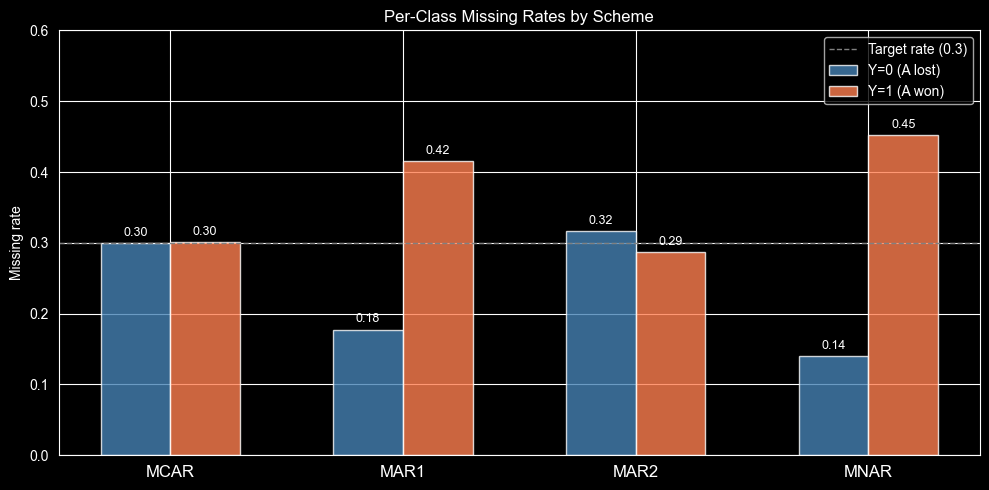

In [20]:
# Visualize: per-class missing rates side by side
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(schemes))
width = 0.3

rates_0 = [
    results[s]["summary"]["missing_rate_class0"] for s in schemes
]
rates_1 = [
    results[s]["summary"]["missing_rate_class1"] for s in schemes
]

bars0 = ax.bar(
    x_pos - width / 2, rates_0, width,
    label="Y=0 (A lost)", color="steelblue", alpha=0.8,
)
bars1 = ax.bar(
    x_pos + width / 2, rates_1, width,
    label="Y=1 (A won)", color="coral", alpha=0.8,
)

ax.axhline(
    MISSING_RATE, color="gray", linestyle="--", linewidth=1,
    label=f"Target rate ({MISSING_RATE})",
)
ax.set_xticks(x_pos)
ax.set_xticklabels(schemes, fontsize=12)
ax.set_ylabel("Missing rate")
ax.set_title("Per-Class Missing Rates by Scheme")
ax.legend()
ax.set_ylim(0, 0.6)

for bar_group in [bars0, bars1]:
    for bar in bar_group:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## 8. Save Obfuscated Datasets

For each scheme, we save the dataset with `y_obs` (where −1 = missing) alongside the true `y_true` for later evaluation.

In [21]:
for scheme_name in schemes:
    df_out = X_final.copy()
    df_out["y_obs"] = results[scheme_name]["y_obs"]
    df_out["y_true"] = y_final

    out_path = os.path.join(PROCESSED_DIR, f"atp_upset_{scheme_name}.csv")
    df_out.to_csv(out_path, index=False)

    n_missing = (df_out["y_obs"] == -1).sum()
    print(
        f"Saved {scheme_name:5s} -> {out_path} | "
        f"{n_missing}/{len(df_out)} labels missing "
        f"({n_missing / len(df_out):.1%})"
    )

print("\nDone! All datasets saved.")

Saved MCAR  -> /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/Project 1/processed/atp_upset_MCAR.csv | 28266/94131 labels missing (30.0%)
Saved MAR1  -> /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/Project 1/processed/atp_upset_MAR1.csv | 27963/94131 labels missing (29.7%)
Saved MAR2  -> /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/Project 1/processed/atp_upset_MAR2.csv | 28394/94131 labels missing (30.2%)
Saved MNAR  -> /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/Project 1/processed/atp_upset_MNAR.csv | 27972/94131 labels missing (29.7%)

Done! All datasets saved.


## 9. Quick Sanity Check: Logistic Regression on Fully-Labelled Data

Before proceeding with missing-label experiments, let's verify the dataset works well with logistic regression. We expect good (but not perfect) performance, confirming the features are informative without leaking the target.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, random_state=121553223)),
    ]
)

scores = cross_val_score(pipe, X_final, y_final, cv=5, scoring="accuracy")
print(f"5-fold CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"Individual folds:   {[f'{s:.4f}' for s in scores]}")

auc_scores = cross_val_score(
    pipe, X_final, y_final, cv=5, scoring="roc_auc"
)
print(f"5-fold CV ROC-AUC:  {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}")
print(f"Individual folds:   {[f'{s:.4f}' for s in auc_scores]}")

5-fold CV accuracy: 0.9404 +/- 0.0033
Individual folds:   ['0.9372', '0.9388', '0.9452', '0.9433', '0.9373']
5-fold CV ROC-AUC:  0.9866 +/- 0.0013
Individual folds:   ['0.9861', '0.9854', '0.9887', '0.9874', '0.9855']


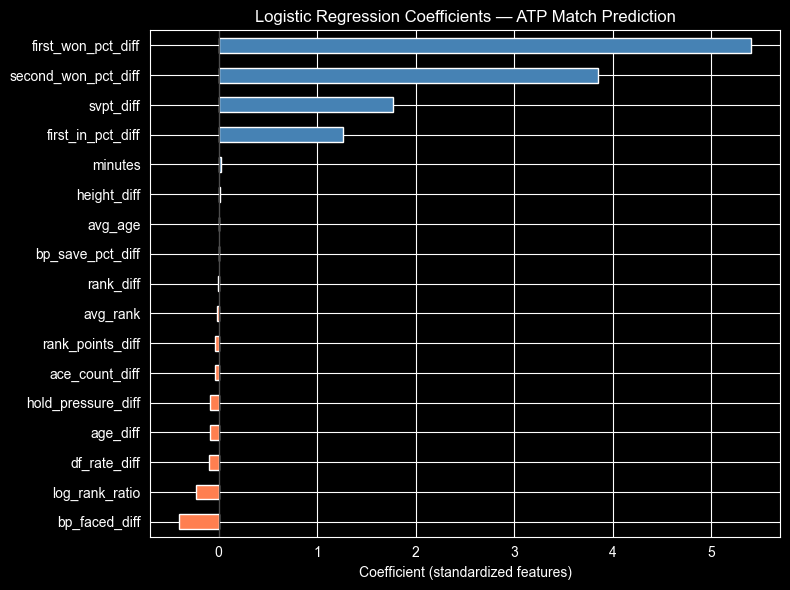

In [23]:
# Feature importance from a fitted LR model
pipe.fit(X_final, y_final)
coefs = pd.Series(
    pipe.named_steps["lr"].coef_[0],
    index=final_features,
).sort_values()

fig, ax = plt.subplots(figsize=(8, max(6, len(final_features) * 0.35)))
coefs.plot.barh(
    ax=ax, color=["coral" if v < 0 else "steelblue" for v in coefs]
)
ax.set_xlabel("Coefficient (standardized features)")
ax.set_title("Logistic Regression Coefficients — ATP Match Prediction")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## Summary

We have:

1. **Loaded** ATP match data (2015–2024), ~25k matches.
2. **Symmetrized** the data by randomly assigning players to A/B positions (coin flip with `seed=0`) to avoid target leakage.
3. **Created** a binary target: **Did Player A win?** (balanced ~50/50).
4. **Engineered** 23 numerical features from match statistics (A−B differentials, rates, match-level).
5. **Preprocessed**: imputed missing values, removed collinear features (correlation + VIF).
6. **Generated** four missing-label datasets (MCAR, MAR1, MAR2, MNAR) at 30% missing rate (using `seed=42`).
7. **Verified** the dataset works with logistic regression (strong but not perfect accuracy/AUC — no leakage).

All processed files are saved in `processed/`:
- `atp_upset.csv` — fully labelled
- `atp_upset_MCAR.csv` — MCAR missing labels
- `atp_upset_MAR1.csv` — MAR1 missing labels
- `atp_upset_MAR2.csv` — MAR2 missing labels
- `atp_upset_MNAR.csv` — MNAR missing labels